# Occupation-resolved decay versus self-Kerr

Read the spectroscopy jobs, reconstruct the complex return amplitude `A(t)`,
fit its decay, and compare initial photon number with Kerr. Run from the top.
All analysis functions live in this notebook. Existing files are only read;
JOB lists, traces, fits, and figures stay in memory.

The fit uses measured **power** `|A(t)|^2`:

$$P(t) = C + B\,|A_{\mathrm{coherent}}(t)|^2\exp[-2(t/\tau_A)^\beta].$$

- Fitted: `C` (power floor), `B` (scale), and `tau_A` (amplitude 1/e time, us).
- Fixed: the coherent return from the Hamiltonian, using the selected K,
  historical g, and saved detunings. No K or g is fitted here.
- `beta=1` is exponential; `beta=2` is Gaussian. Select one in the settings.

The factor 2 appears because power is amplitude squared. Coherent photon
exchange already makes `|A|` oscillate, so it stays in the model. A fitted tau
depends on how well this Hamiltonian describes the trace.

Summary points are unweighted means of accepted trace fits. Bars show one
sample SD across traces; `n=1` has no bar. Initial central photon number means
the occupation at preparation, before photons move between modes.


## 1. Paths and choices

In [31]:
from pathlib import Path
from collections import defaultdict
from hashlib import sha256
from itertools import product
import ast
import json
import os
import re
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from IPython.display import display

# Set this only if the remote kernel starts outside the repository.
REPO_ROOT_OVERRIDE = None
_candidates = [Path.cwd(), *Path.cwd().parents, Path(r"C:\python\multimode_expts")]
REPO_ROOT = (Path(REPO_ROOT_OVERRIDE).expanduser() if REPO_ROOT_OVERRIDE else
             next((p for p in _candidates if (p / "experiments/qsim/floquet_dark_mode_readout.py").is_file()), Path.cwd()))
DATA_ROOT = Path(r"C:\experiments")
CONFIG_VERSIONS_DIR = None  # Set an existing directory to override automatic lookup.
_config_candidates = [REPO_ROOT / "configs/versions", Path(r"S:\Multimode\BF5_config_versions")]
CONFIG_VERSIONS_DIR = (
    Path(CONFIG_VERSIONS_DIR).expanduser() if CONFIG_VERSIONS_DIR is not None else
    next((p for p in _config_candidates
          if any((p / "floquet_storage_swap").glob("CFG-FL-*.csv"))),
         _config_candidates[0])
)
CLOCK_SNAPSHOT_PATH = REPO_ROOT / "configs/soccfg_snapshot.json"
JOB_DOCUMENT = REPO_ROOT / "docs/spectroscopy job id compilation/Only JOB IDs for Agents.md"
KERR_SOURCE = "document"  # "document" or "saved"; never inferred from decay fits.
DATASET_IDS = None       # None loads every curated dataset; e.g. ["1.3", "2.1", "4.1"].
FIT_MIN_US = 0.0
FIT_MAX_US = None        # None uses each trace's full available time window.
PLOT_ENVELOPE = "exponential"  # "exponential" or "gaussian"; one model per run.
TRACE_DATASET_IDS = None
TRACE_PURE_CENTRAL = True  # First diagnostics; False also displays storage-populated states.
KERR_PURE_CENTRAL = False  # False includes n_M1=2 with another photon in a storage mode.
PHOTON_VIEW_MODE = "M1"  # Any acquired mode, e.g. "S1" or "S4".
print(f"Repository: {REPO_ROOT}\nHDF5 root: {DATA_ROOT}\nConfig versions: {CONFIG_VERSIONS_DIR}\nKerr source: {KERR_SOURCE}")

Repository: C:\python\multimode_expts
HDF5 root: C:\experiments
Config versions: C:\python\multimode_expts\configs\versions
Kerr source: document


## 2. Documented JOB IDs

The current JOB-ID document is read when present. The compact list below has
the same 14 datasets and 1,885 spectroscopy JOB IDs for remote use.
`20260722:215-229,231-243` means inclusive ranges, excluding job 230;
`577-595/2` means every second job. Each `r` is the displayed group label.
Calibration IDs are references: a phase-only rotation does not change `|A|^2`.


In [32]:
# JOB ranges are inclusive: "20260722:577-595/2" means 577, 579, ..., 595.
# Space-separated date blocks allow a realization to span multiple days.
def job_ids(ranges):
    jobs = []
    for block in ranges.split():
        date, numbers = block.split(":")
        for token in numbers.split(","):
            bounds, *stride = token.split("/")
            first, *last = map(int, bounds.split("-"))
            stop = last[0] if last else first
            step = int(stride[0]) if stride else 1
            jobs.extend(f"JOB-{date}-{number:05d}" for number in range(first, stop + 1, step))
    return jobs


# Each tuple: dataset ID, nominal g/K (kHz), folder, config, title,
# calibration JOB ranges, and spectroscopy JOB ranges by displayed r.
# r is a bookkeeping label; it need not equal the saved realization value.
JULY = "260526_qsim_darkmode"
AUGUST = "260818_qsim_spectroscopy"

In [33]:
job_catalog = [
    ('1.1', 15.0, 19.2, JULY, 'CFG-FL-20260717-00028',
     'Disordered Full N = 1', '20260722:557-566', {
         None: '20260722:577-595/2',
     }),
    ('1.2', 15.0, 19.2, JULY, 'CFG-FL-20260722-00001',
     'Disorderless Partial N =2', '20260722:35-64', {
         None: '20260722:215-229,231-243',
     }),
    ('1.2-1', 15.0, 19.2, JULY, 'CFG-FL-20260722-00001',
     'Missing One element for N =2', '20260722:425,426', {
         None: '20260722:452,454',
     }),
    ('1.3', 15.0, 19.2, JULY, 'CFG-FL-20260722-00001',
     'Disorderless Full N = 3', '20260722:683-712 20260723:1-40', {
         None: '20260723:48-85,87-149/2',
     }),
    ('1.4', 15.0, 19.2, JULY, 'CFG-FL-20260717-00028',
     'Disorderless Full N = 1', '20260721:423-432', {
         None: '20260722:5-14',
     }),
    ('2.1', 8.61, 5.7, JULY, 'CFG-FL-20260814-00076',
     'Disorderless Full N = 3', '20260815:113-182', {
         None: '20260815:183-242 20260816:1-10',
     }),
    ('2.2', 8.61, 5.7, JULY, 'CFG-FL-20260814-00076',
     'Disordered Partial N = 3', '20260815:113-182', {
         0: '20260816:13-32',
         1: '20260816:33-52',
         2: '20260816:53-72',
         3: '20260817:1-20',
     }),
    ('3.1', 15.2, 44.96, AUGUST, 'CFG-FL-20260825-00097',
     'Disordered Partial N = 3', '20260828:289-358', {
         0: '20260829:16-35',
         1: '20260829:36-55',
         2: '20260829:56-75',
         3: '20260829:76-95',
         4: '20260829:96-115',
         5: '20260829:116-135',
         6: '20260829:136-155',
         7: '20260829:156-175',
         8: '20260829:176-195',
         9: '20260829:196-215',
         10: '20260829:216-235',
         11: '20260829:236-255',
         12: '20260829:256-271 20260830:1-4',
         13: '20260830:5-24',
         14: '20260830:25-44',
         15: '20260830:45-64',
         16: '20260830:65-84',
         17: '20260830:85-104',
         18: '20260830:105-124',
         19: '20260830:125-134',
     }),
    ('4.1', 29.2, 3.6, AUGUST, 'CFG-FL-20260909-00042',
     'Disordered Full N = 3', '20260909:152-211 20260910:1-10', {
         0: '20260910:31-72 20260911:46,47,49,50,52,53,55,56,58,59,61,62,64,65,67,68,70,71,73,74,76,77,79,80,82,83,85,86',
         1: '20260912:33,34,36,37,39,40,42,43,45,46,48,49,51,52,54,55,57,58,60,61,63,64,66,67,69,70,72,73,75,76,78,79,81,82,84,85,87,88,90,91,93,94,96,97,99,100,102,103,105,106,108,109,111,112,114,115,117,118,120,121,123,124,126,127,129,130,132,133,135,136',
         2: '20260912:138,139,141,142,144,145,147,148,150,151,153,154,156,157,159,160,162,163,165,166,168,169,171,172,174,175,177,178,180,181,183,184,186,187,189,190,192,193,195,196,198,199,201,202,204,205,207,208,210,211,213,214,216,217,219,220,222,223,225,226,228,229,231,232,234,235,237,238,240,241',
         3: '20260912:243,244,246,247,249,250,252,253,255,256,258,259,261,262,264,265,267,268,270,271,273,274,276,277,279,280,282,283,285,286,288,289,291,292,294,295,297,298,300,301,303,304,306,307,309,310,312,313,315,316,318,319,321,322,324,325,327,328,330,331,333,334,336,337,339,340,342,343,345,346',
         4: '20260912:348,349,351,352,354,355,357,358,360,361,363,364,366,367,369,370,372,373,375,376,378,379,381,382,384,385,387,388 20260913:2,3,5,6,8,9,11,12,14,15,17,18,20,21,23,24,26,27,29,30,32,33,35,36,38,39,41,42,44,45,47,48,50,51,53,54,56,57,59,60,62,63',
         5: '20260913:65,66,68,69,71,72,74,75,77,78,80,81,83,84,86,87,89,90,92,93,95,96,98,99,101,102,104,105,107,108,110,111,113,114,116,117,119,120,122,123,125,126,128,129,131,132,134,135,137,138,140,141,143,144,146,147,149,150,152,153,155,156,158,159,161,162,164,165,167,168',
         6: '20260913:170,171,173,174,176,177,179,180,182,183,185,186,188,189,191,192,194,195,197,198,200,201,203,204,206,207,209,210,212,213,215,216,218,219,221,222,224,225,227,228,230,231,233,234,236,237,239,240,242,243,245,246,248,249,251,252,254,255,257,258,260,261,263,264,266,267,269,270,272,273',
         7: '20260913:275,276,278,279,281,282,284,285,287,288,290,291,293,294,296,297,299,300,302,303,305,306,308,309,311,312,314,315,317,318,320,321,323,324,326,327,329,330,332,333,335,336,338,339,341,342,344,345,347,348,350,351,353,354,356,357,359,360,362,363,365,366,368,369,371,372,374,375,377,378',
         8: '20260913:380,381,383,384,386,387,389,390,392,393,395,396,398,399 20260914:2,3,5,6,8,9,11,12,14,15,17,18,20,21,23,24,26,27,29,30,32,33,35,36,38,39,41,42,44,45,47,48,50,51,53,54,56,57,59,60,62,63,65,66,68,69,71,72,74,75,77,78,80,81,83,84',
     }),
    ('5', 29.2, 52.3, AUGUST, 'CFG-FL-20260906-00041',
     '5. g = 29.2 kHz, K = 52.3 kHz', '20260907:199-268', {
         0: '20260907:304-333',
         1: '20260907:334-363',
         2: '20260907:364-393',
         3: '20260907:406-415 20260908:1-20',
         4: '20260908:21-50',
         5: '20260908:51-80',
     }),
    ('6', 30.0, 3.6, AUGUST, 'CFG-FL-20260905-00045',
     '6. g = 30 kHz, K = 3.6 kHz', '20260905:75-144', {
         0: '20260905:145-159',
         1: '20260905:160-174',
     }),
    ('7', 15.0, 44.0, AUGUST, 'CFG-FL-20260831-00092',
     '7. g = 15 kHz, K = 44 kHz', '20260831:479-548', {
         0: '20260901:3-12',
         1: '20260901:13-22',
         2: '20260901:23-32',
         3: '20260901:33-42',
         4: '20260901:43-52',
     }),
    ('8', 15.0, 20.0, AUGUST, 'CFG-FL-20260901-00034',
     '8. g = 15 kHz, K = 20 kHz', '20260902:1-70', {
         0: '20260902:71-80',
         1: '20260902:81-90',
         2: '20260902:91-94,96,97,99,100,102,103',
         3: '20260902:105,106,108,109,111,112,114,115,117,118',
         4: '20260902:120,121,123,124,126,127,129,130,132,133',
     }),
    ('9', 15.0, 3.6, AUGUST, 'CFG-FL-20260902-00121',
     '9. g = 15 kHz, K = 3.6 kHz', '20260902:768-837', {
         0: '20260902:840,841 20260903:1-13',
         1: '20260903:14-28',
         2: '20260903:29-43',
         3: '20260903:44-58',
         4: '20260903:59,60,62,63,65,66,68,69,71,72,74,75,77,78,80',
         5: '20260903:82,83,85,86,88,89,91,92,94,95,97,98,100,101,103',
         6: '20260903:105,106,108,109,111,112,114,115,117,118,120,121,123,124,126',
         7: '20260903:128,129,131,132,134,135,137,138,140,141,143,144,146-148',
         8: '20260903:149-163',
         9: '20260903:164-178',
         10: '20260903:179-193',
         11: '20260903:194-203 20260904:1-5',
         12: '20260904:6-20',
         13: '20260904:21-35',
         14: '20260904:36-50',
         15: '20260904:51-65',
         16: '20260904:66-80',
         17: '20260904:81-95',
         18: '20260904:96-110',
     }),
]

In [34]:
datasets = [dict(
    dataset_id=id_, nominal_g_kHz=g, nominal_K_kHz=K, folder=folder,
    floquet_config_version=config, dataset_title=title,
    group_title=f"g = {g:g} kHz, K = {K:g} kHz",
    calibration_job_ids=job_ids(calibration),
    spectroscopy_job_ids_by_r={r: job_ids(jobs) for r, jobs in spectroscopy.items()},
) for id_, g, K, folder, config, title, calibration, spectroscopy in job_catalog]


def read_job_document(path):
    """Read the current g/K sections and JOB lists from the curated document."""
    text = path.read_text(encoding="utf-8-sig")
    headings = list(re.finditer(r"(?m)^# (\d+)\. g = ([\d.]+) kHz, K = ([\d.]+) kHz", text))
    records = []
    for index, heading in enumerate(headings):
        group, g, K = heading.groups()
        stop = headings[index + 1].start() if index + 1 < len(headings) else len(text)
        body = text[heading.end():stop]
        subheadings = list(re.finditer(r"(?m)^## ([\d-]+)\. (.+)", body))
        sections = [(group, heading.group(0)[2:], body)]
        if subheadings:
            sections = []
            for subindex, subheading in enumerate(subheadings):
                substop = subheadings[subindex + 1].start() if subindex + 1 < len(subheadings) else len(body)
                sections.append((f"{group}.{subheading[1]}", subheading[2], body[subheading.end():substop]))
        for id_, title, content in sections:
            fields = list(re.finditer(r"(?m)^- (Folder|Foler|Config|Calibration_job_ids|Spec_job_ids)(?::|\s)", content))
            values = {}
            for fieldindex, field in enumerate(fields):
                fieldstop = fields[fieldindex + 1].start() if fieldindex + 1 < len(fields) else len(content)
                values[field[1]] = content[field.end():fieldstop].strip()
            spectroscopy = values["Spec_job_ids"]
            spectroscopy = ast.literal_eval(spectroscopy) if spectroscopy.startswith("{") else {None: re.findall(r"JOB-\d{8}-\d{5}", spectroscopy)}
            records.append(dict(
                dataset_id=id_, dataset_title=title, group_title=heading.group(0)[2:],
                nominal_g_kHz=float(g), nominal_K_kHz=float(K),
                folder=values.get("Folder", values.get("Foler")).strip("\"' \u2018\u2019\u201c\u201d"),
                floquet_config_version=re.search(r"CFG-FL-\d{8}-\d{5}", values["Config"])[0],
                calibration_job_ids=re.findall(r"JOB-\d{8}-\d{5}", values["Calibration_job_ids"]),
                spectroscopy_job_ids_by_r=spectroscopy,
            ))
    return records


# Use the document when available; the compact catalog above works on a remote
# kernel whose checkout does not contain the document. Everything stays in memory.
if JOB_DOCUMENT.is_file():
    datasets = read_job_document(JOB_DOCUMENT)
if DATASET_IDS is not None:
    datasets = [dataset for dataset in datasets if dataset["dataset_id"] in DATASET_IDS]

## 3. Read the measured amplitude

`readout_quadrature` normalizes saved averages by `Ig`/`Ie` and takes the
preparation-phase difference. `reconstruct_return` joins time chunks and forms
`A = Q(0) - i Q(90)`. Each occupation keeps its own measured time grid.


In [35]:
def read_spectroscopy_job(path):
    """Read saved averages and config in one read-only HDF5 open."""
    with h5py.File(path, "r") as h5:
        cfg = json.loads(h5.attrs["config"])
        if "spectroscopy_occupations" not in cfg["expt"]:
            raise ValueError("Not occupation spectroscopy")
        arrays = {name: np.asarray(h5[name]) for name in ("avgi", "xpts", "ypts")}
        hardware = json.loads(h5.attrs["spectroscopy_hardware"]) if "spectroscopy_hardware" in h5.attrs else None
    return dict(path=path, cfg=cfg, arrays=arrays, hardware=hardware)


def readout_quadrature(job):
    """Preparation-phase difference, normalized by saved ground/excited readout."""
    cfg, arrays = job["cfg"], job["arrays"]
    assert np.allclose(arrays["xpts"], [0, 180]), "Expected preparation phases 0 and 180"
    qubit = cfg["expt"]["qubits"][0]
    readout = cfg["device"]["readout"]
    ground, excited = readout["Ig"][qubit], readout["Ie"][qubit]
    population = (arrays["avgi"].reshape(-1, 2) - ground) / (excited - ground)
    return population[:, 0] - population[:, 1]


def reconstruct_return(jobs):
    """Join measured chunks and pair analyzer phases: A = Q(0) - i Q(90)."""
    chunks = defaultdict(list)
    interleaved = "offdiag_cycles" in jobs[0]["cfg"]["expt"]
    for job in jobs:
        expt = job["cfg"]["expt"]
        quadrature = readout_quadrature(job)
        if interleaved:
            cycles = np.asarray(expt["offdiag_cycles"], dtype=float)
            quadrature = quadrature.reshape(-1, 2)
            rotation = np.exp(-1j * np.deg2rad(expt["offdiag_decoder_phase_correction_deg"] * cycles))
            chunks["complex"].append((cycles, (quadrature[:, 0] - 1j * quadrature[:, 1]) * rotation))
        else:
            cycles = job["arrays"]["ypts"]
            assert np.array_equal(cycles, expt["floquet_cycles"]), "Cycle axis differs from saved config"
            chunks[float(expt["spectroscopy_analyzer_phase"])].append((cycles, quadrature))
    joined = {}
    for phase, parts in chunks.items():
        cycles = np.concatenate([part[0] for part in parts])
        values = np.concatenate([part[1] for part in parts])
        order = np.argsort(cycles)
        cycles, values = cycles[order], values[order]
        assert len(np.unique(cycles)) == len(cycles), "Duplicate cycle points"
        joined[phase] = cycles, values
    if interleaved:
        return joined["complex"]
    cycles, real = joined[0.0]
    imag_cycles, imag = joined[90.0]
    assert np.array_equal(cycles, imag_cycles), "Analyzer phases have different cycle grids"
    return cycles, real - 1j * imag

### Convert cycles to microseconds and read g

Use saved HDF5 timing when available. Older jobs require their exact historical
Floquet CSV and the RFSoC clock snapshot. Pulse lengths are rounded to hardware
ticks before summing a Floquet cycle; the current calibration CSV is not used.


In [36]:
def hardware_timing(job, version, versions_dir, snapshot_path, table_cache):
    """Use saved T/g, otherwise reproduce pulse clock rounding from historical CSV."""
    expt, cfg = job["cfg"]["expt"], job["cfg"]
    if job["hardware"] is not None:
        saved = job["hardware"]
        return float(saved["floquet_cycle_us"]), np.asarray(saved["couplings_MHz"]), "HDF5 spectroscopy_hardware"
    if version not in table_cache:
        path = versions_dir / "floquet_storage_swap" / f"{version}.csv"
        table_cache[version] = pd.read_csv(path).set_index("stor_name")
    table = table_cache[version]
    rows = [table.loc[f"M1-S{mode}"] for mode in expt["swap_stors"]]
    pi_fractions = np.asarray([row["pi_frac"] for row in rows])
    if expt.get("floquet_cycle_us") is not None:
        cycle_us = float(expt["floquet_cycle_us"])
        source = f"HDF5 cycle time + CSV {version}"
    else:
        if "clock" not in table_cache:
            table_cache["clock"] = json.loads(snapshot_path.read_text(encoding="utf-8"))
        clocks = table_cache["clock"]
        processor_clock = clocks["tprocs"][0]["f_time"]
        ramp_sigma = np.asarray(cfg["device"]["manipulate"]["ramp_sigma"]).reshape(-1)[0]
        processor_ticks = 0
        for row in rows:
            flux = "flux_low" if row["freq (MHz)"] < 1800 else "flux_high"
            channel = cfg["hw"]["soc"]["dacs"][flux]["ch"][0]
            pulse_clock = clocks["gens"][channel]["f_fabric"]
            ticks = lambda duration: int(np.round(float(duration) * pulse_clock))
            waveform = expt.get("floquet_waveform") or row.get("waveform", "flat_top")
            if waveform in ("gauss", "gaussian", "arb"):
                sigma = expt.get("floquet_gauss_sigma")
                sigma = row.get("gauss_sigma (mus)", -1) if sigma is None else sigma
                pulse_ticks = ticks(sigma) * int(row.get("gauss_n_sigma", 4))
            elif waveform == "preload_flattop":
                pulse_ticks = ticks(row["len (mus)"]) + 6 * ticks(row["ramp_sigma (mus)"])
            else:
                pulse_ticks = ticks(row["len (mus)"]) + 6 * ticks(ramp_sigma)
            processor_ticks += int(pulse_ticks * (processor_clock / pulse_clock) + expt.get("scramble_sync_cycles", 10))
        cycle_us = processor_ticks / processor_clock
        source = f"CSV {version} + HDF5 pulse settings + RFSoC clocks"
    couplings = 1 / (4 * pi_fractions * cycle_us)
    return cycle_us, couplings, source

### Calculate the coherent return

Build `H/h` in the fixed-total-photon basis. Its diagonal contains storage
detunings and central Kerr `K*n*(n-1)/2`; its off-diagonal terms exchange one
photon with coupling `g*sqrt(n_central*(n_storage+1))`.
The eigenstate weights give the return amplitude without decay.


In [37]:
def coherent_return(occupation, time_us, detunings, couplings, kerr_MHz, cache):
    """Return amplitude under H/h, before decay: <occupation|exp(-2 pi i H t)|occupation>."""
    N = sum(occupation)
    key = N, len(occupation), tuple(detunings), tuple(couplings), kerr_MHz
    if key not in cache:
        basis = [state for state in product(range(N + 1), repeat=len(occupation)) if sum(state) == N]
        index = {state: row for row, state in enumerate(basis)}
        H = np.zeros((len(basis), len(basis)))
        for column, state in enumerate(basis):
            central = state[0]
            H[column, column] = -np.dot(detunings, state[1:]) + kerr_MHz * central * (central - 1) / 2
            if central == 0:
                continue
            for mode, g in enumerate(couplings, start=1):
                final = list(state)
                final[0] -= 1
                final[mode] += 1
                row = index[tuple(final)]
                element = g * np.sqrt(central * (state[mode] + 1))
                H[row, column] += element
                H[column, row] += element
        energies, states = np.linalg.eigh(H)
        cache[key] = energies, states, index
    energies, states, index = cache[key]
    weights = abs(states[index[occupation]]) ** 2
    return weights @ np.exp(-2j * np.pi * np.outer(energies, time_us))

### Collect the requested traces

Only diagonal returns (same initial and final occupation) enter this study.
Analyzer jobs are paired within their saved physical condition. The loading
table reports unused jobs and failed reads; it does not average their data.


In [38]:
def saved_kerr_kHz(job):
    """Read the selected manipulate cavity's Kerr magnitude, in kHz."""
    values = np.asarray(job["cfg"]["device"]["manipulate"]["kerr"]).reshape(-1)
    mode_index = job["cfg"]["expt"].get("man_mode_no", 1) - 1
    return float(abs(values[0 if len(values) == 1 else mode_index]) * 1000)


def physical_condition(job):
    """Keep different saved pulse settings apart when pairing analyzer jobs."""
    expt = job["cfg"]["expt"]
    fields = ("swap_stors", "man_mode_no", "floquet_waveform", "floquet_gauss_sigma", "scramble_sync_cycles",
              "use_multiphoton_swap", "floquet_cycle_us", "decoder_cycle_us", "spectroscopy_phase_correction_mode",
              "final_analyzer_phase_per_cycle_deg", "final_analyzer_phase_application_sign", "offdiag_decoder_phase_correction_deg")
    settings = {field: expt.get(field) for field in fields}
    hardware = job["hardware"]
    settings["hardware"] = None if hardware is None else {field: hardware.get(field) for field in ("floquet_cycle_us", "couplings_MHz", "decoder_cycle_us")}
    detunings = expt.get("detunings") or [0.] * len(expt["swap_stors"])
    settings["detunings"] = np.asarray(detunings, dtype=float).tolist()
    settings["kerr"] = saved_kerr_kHz(job)
    settings["interleaved"] = "offdiag_cycles" in expt
    return json.dumps(settings, sort_keys=True)


def load_decay_traces(manifest, base_dir, repo_root, *, kerr_source="document",
                      config_versions_dir=None, clock_snapshot_path=None, progress=True):
    """Read documented jobs; keep per-trace grids and report unused jobs in a table."""
    versions = Path(config_versions_dir) if config_versions_dir is not None else Path(repo_root) / "configs/versions"
    snapshot = Path(clock_snapshot_path) if clock_snapshot_path is not None else Path(repo_root) / "configs/soccfg_snapshot.json"
    files, tables, theory_cache = {}, {}, {}
    for folder in dict.fromkeys(dataset["folder"] for dataset in manifest):
        files[folder] = defaultdict(list)
        with os.scandir(Path(base_dir) / folder / "data") as entries:
            for entry in entries:
                if entry.name.endswith(".h5"):
                    files[folder][entry.name[:18]].append(Path(entry.path))
    traces, audit = [], []
    for dataset in manifest:
        if progress:
            print(f"Dataset {dataset['dataset_id']}: {dataset['dataset_title']}", flush=True)
        for realization, ids in dataset["spectroscopy_job_ids_by_r"].items():
            groups = defaultdict(list)
            for job_id in ids:
                entry = dict(dataset_id=dataset["dataset_id"], realization=realization, job_id=job_id, status="used", reason="")
                audit.append(entry)
                try:
                    candidates, rejections = [], []
                    for path in files[dataset["folder"]][job_id]:
                        try:
                            candidates.append(read_spectroscopy_job(path))
                        except (KeyError, ValueError) as error:
                            rejections.append(f"{path.name}: {error}")
                    if len(candidates) != 1:
                        raise ValueError(f"Expected one spectroscopy file; found {len(candidates)}. " + "; ".join(rejections))
                    job = candidates[0]
                    expt = job["cfg"]["expt"]
                    initial = tuple(expt["spectroscopy_occupations"])
                    final = tuple(expt.get("offdiag_decoder_occupation", expt.get("spectroscopy_final_occupations", initial)))
                    if initial != final:
                        entry.update(status="excluded_nonreturn", reason="Initial and final occupations differ")
                        continue
                    entry.update(path=str(job["path"]), occupation=initial)
                    groups[initial, physical_condition(job)].append((job_id, job, entry))
                except (OSError, KeyError, ValueError, TypeError) as error:
                    entry.update(status="read_error", reason=str(error))
            for (occupation, condition), items in groups.items():
                try:
                    jobs = [item[1] for item in items]
                    first, expt = jobs[0], jobs[0]["cfg"]["expt"]
                    cycles, A = reconstruct_return(jobs)
                    cycle_us, g, hardware_source = hardware_timing(first, dataset["floquet_config_version"], versions, snapshot, tables)
                    saved_K = saved_kerr_kHz(first)
                    K = abs(dataset["nominal_K_kHz"]) if kerr_source == "document" else saved_K
                    detunings = np.asarray(expt.get("detunings") or np.zeros(len(g)), dtype=float)
                    time_us = cycles * cycle_us
                    theory_A = coherent_return(occupation, time_us, detunings, g, -K / 1000, theory_cache)
                    strength_key = None
                    for key in ("disorder_strength_kHz", "diagonal_disorder_strength_kHz", "d72_disorder_strength_kHz"):
                        values = [job["cfg"]["expt"].get(key) for job in jobs]
                        if all(value is not None for value in values) and np.allclose(values, values[0], rtol=0, atol=1e-6):
                            strength_key = key
                            break
                    strength = expt[strength_key] if strength_key else 1000 * np.sqrt(np.mean(detunings ** 2))
                    stored_fields = {}
                    for key in ("disorder_realization", "diagonal_disorder_realization", "d72_realization", "realization"):
                        values = sorted({int(job["cfg"]["expt"][key]) for job in jobs if job["cfg"]["expt"].get(key) is not None})
                        if values:
                            stored_fields[key] = values
                    stored_values = sorted({value for values in stored_fields.values() for value in values})
                    stored_r = stored_values[0] if len(stored_values) == 1 else tuple(stored_values) if stored_values else None
                    condition_id = sha256(condition.encode()).hexdigest()[:12]
                    trace_id = f"{dataset['dataset_id']}/r={realization}/condition={condition_id}/occupation={occupation}"
                    traces.append(dict(
                        trace_id=trace_id, condition_id=condition_id,
                        dataset_id=dataset["dataset_id"], dataset_title=dataset["dataset_title"],
                        group_title=dataset["group_title"], folder=dataset["folder"],
                        realization=realization, stored_realization=stored_r, occupation=occupation,
                        stored_realization_fields=stored_fields, final_occupation=occupation,
                        mode_labels=["M1"] + [f"S{mode}" for mode in expt["swap_stors"]],
                        n_central=occupation[0], total_photons=sum(occupation), time_us=time_us, cycles=cycles,
                        A=A, coherent_A=theory_A, floquet_cycle_us=cycle_us,
                        K_kHz=K, document_K_kHz=float(dataset["nominal_K_kHz"]), saved_K_kHz=saved_K,
                        saved_signed_K_kHz=-saved_K, theory_signed_K_kHz=-K, kerr_source=kerr_source,
                        g_kHz=(g * 1000).tolist(), g_mean_kHz=float(np.mean(g) * 1000),
                        nominal_g_kHz=float(dataset["nominal_g_kHz"]),
                        detunings_kHz=(detunings * 1000).tolist(), disorder_strength_kHz=strength,
                        disorder_strength_source=f"saved {strength_key}" if strength_key else "RMS of saved pulse detunings",
                        job_ids=[item[0] for item in items], calibration_job_ids=dataset["calibration_job_ids"],
                        job_paths=[str(job["path"]) for job in jobs], calibration_used=False,
                        documented_disorder=dataset.get("documented_disorder"),
                        config_version=dataset["floquet_config_version"], hardware_source=hardware_source,
                        source_path=dataset.get("source_path"), source_line=dataset.get("source_line"),
                        phase_frame="as_acquired", fit_observable="return_power"))
                    for _, _, entry in items:
                        entry["trace_id"] = trace_id
                except (OSError, KeyError, ValueError, TypeError, AssertionError) as error:
                    for _, _, entry in items:
                        entry.update(status="trace_error", reason=str(error))
    return traces, pd.DataFrame(audit)

In [39]:
traces, fit_results, fit_details = [], pd.DataFrame(), {}
traces, loading_audit = load_decay_traces(
    datasets, DATA_ROOT, REPO_ROOT, kerr_source=KERR_SOURCE,
    config_versions_dir=CONFIG_VERSIONS_DIR, clock_snapshot_path=CLOCK_SNAPSHOT_PATH,
)
print(f"Loaded {len(traces)} occupation traces.")
display(loading_audit.groupby("status").size().rename("jobs").to_frame())
failures = loading_audit.loc[~loading_audit.status.isin(["used", "excluded_nonreturn"])]
if not failures.empty:
    print(failures[["dataset_id", "realization", "status", "reason"]].drop_duplicates().to_string(index=False))
if not traces:
    raise RuntimeError(f"No traces loaded. Check the failures and config root: {CONFIG_VERSIONS_DIR}")

Dataset 1.1: Disordered Full N = 1
Dataset 1.2: Disorderless Partial N =2
Dataset 1.2-1: Missing One element for N =2
Dataset 1.3: Disorderless Full N = 3
Dataset 1.4: Disorderless Full N = 1
Dataset 2.1: Disorderless Full N = 3
Dataset 2.2: Disordered Partial N = 3
Dataset 3.1: Disordered Partial N = 3
Dataset 4.1: Disordered Full N = 3
Dataset 5: 5. g = 29.2 kHz, K = 52.3 kHz
Dataset 6: 6. g = 30 kHz, K = 3.6 kHz
Dataset 7: 7. g = 15 kHz, K = 44 kHz
Dataset 8: 8. g = 15 kHz, K = 20 kHz
Dataset 9: 9. g = 15 kHz, K = 3.6 kHz
Loaded 972 occupation traces.


,jobs
status,
excluded_nonreturn,188
used,1697


## 4. Fit the power decay

This is the full fitting equation. `floor` and `scale` compensate for readout
offset and amplitude. `tau_us` is the decay time being investigated.


In [40]:
def decay_power(times_us, coherent_power, floor, scale, tau_us, beta):
    """Amplitude envelope exp[-(t/tau)^beta]; its square multiplies power."""
    power_envelope = np.exp(-2 * (times_us / tau_us) ** beta)
    return floor + scale * coherent_power * power_envelope

### Find the parameters

`least_squares` minimizes model-minus-measurement residuals. It fits `log(tau)`
so tau stays positive. Five initial tau guesses help avoid a local minimum.
The extra fit without decay checks whether adding tau improves the fit;
AICc accounts for its additional parameter.


In [41]:
def aicc(residual, parameter_count):
    """Compare residual size while penalizing extra fitted parameters."""
    n = len(residual)
    residual_sum = max(float(residual @ residual), n * 1e-14)
    return (n * np.log(residual_sum / n) + 2 * parameter_count
            + 2 * parameter_count * (parameter_count + 1) / (n - parameter_count - 1))


def solve_decay_power(t, measured_power, coherent_power, beta, tau_bounds):
    """Fit floor, scale and log(tau); compare five guesses to avoid a local minimum."""
    settings = dict(ftol=1e-11, xtol=1e-11, gtol=1e-11)
    no_decay = least_squares(
        lambda p: p[0] + p[1] * coherent_power - measured_power,
        [0.01, 0.8], bounds=([0, 0], [1, np.inf]), **settings)

    def residual(parameters):
        floor, scale, log_tau = parameters
        prediction = decay_power(t, coherent_power, floor, scale, np.exp(log_tau), beta)
        return prediction - measured_power

    span = t[-1] - t[0]
    guesses = np.unique(np.clip(
        span * np.array([0.15, 0.5, 1, 3, 10]), tau_bounds[0] * 1.01, tau_bounds[1] / 1.01))
    solutions = []
    for tau_guess in guesses:
        initial = [min(measured_power.min(), 0.05), max(no_decay.x[1], 0.5), np.log(tau_guess)]
        solution = least_squares(residual, initial,
            bounds=([0, 0, np.log(tau_bounds[0])], [1, np.inf, np.log(tau_bounds[1])]),
            max_nfev=3000, **settings)
        solutions.append(solution)
    best = min(solutions, key=lambda solution: float(solution.fun @ solution.fun))
    return best, no_decay

### Prepare one trace, fit, and report tau

Follow the five numbered steps below. Normalization helps the optimizer;
returned curves use the original power units. `tau_estimate_us` keeps the
optimizer result. `tau_us` is included in averages only when `accepted` is true.

The existing fit checks remain: decay must improve AICc by 6, tau must avoid
the bounds and be constrained by the data, and relative RMSE must be at most
0.35. Fit intervals describe local fit uncertainty; summary SD bars describe
the spread between different traces.


In [42]:
def fit_complex_decay(times_us, A, coherent_A, *, beta=1):
    """Fit |A|^2 = floor + scale*|A_coherent|^2*exp[-2*(t/tau)^beta]."""
    # 1. Use measured power and the coherent return power, with the same time origin.
    t = np.asarray(times_us, dtype=float)
    measured_power, coherent_power = np.abs(A)**2, np.abs(coherent_A)**2
    if len(t) < 8 or np.any(np.diff(t) <= 0) or t[0] < 0:
        raise ValueError("Use at least eight strictly increasing nonnegative times")
    if not np.all(np.isfinite([t, measured_power, coherent_power])):
        raise ValueError("Times and amplitudes must be finite and aligned")
    if measured_power.max() == 0 or coherent_power.max() == 0:
        raise ValueError("Measured and coherent powers must be nonzero")
    measured_norm, coherent_norm = measured_power.max(), coherent_power.max()
    y, c = measured_power / measured_norm, coherent_power / coherent_norm

    # 2. Fit positive tau by optimizing log(tau); normalization only helps the solver.
    tau_bounds = (np.diff(t).min() / 4, 100 * t[-1])
    fit, no_decay = solve_decay_power(t, y, c, beta, tau_bounds)
    floor, scale, log_tau = fit.x
    tau = float(np.exp(log_tau))
    model_power = decay_power(t, c, floor, scale, tau, beta) * measured_norm
    relative_rmse = float(np.sqrt(np.mean(fit.fun**2) / np.mean(y**2)))
    decay_aicc = aicc(fit.fun, 3)
    delta_aicc = aicc(no_decay.fun, 2) - decay_aicc

    # 3. Estimate uncertainty in log(tau) from the local fit curvature.
    log_tau_error = np.nan
    if np.linalg.matrix_rank(fit.jac) == 3:
        residual_variance = (fit.fun @ fit.fun) / (len(t) - 3)
        covariance = np.linalg.pinv(fit.jac.T @ fit.jac) * residual_variance
        log_tau_error = float(np.sqrt(max(covariance[2, 2], 0)))
    lower_tau, upper_tau = np.exp(np.clip(
        log_tau + np.array([-1, 1]) * 1.96 * log_tau_error, -700, 700))

    # 4. Exclude unsupported, unconstrained or poorly described decay estimates.
    status = "accepted"
    if not fit.success or not no_decay.success:
        status = "optimizer_failed"
    elif delta_aicc < 6:
        status = "no_decay_evidence"
    elif tau <= 1.02 * tau_bounds[0] or tau >= tau_bounds[1] / 1.02:
        status = "tau_at_boundary"
    elif (not np.isfinite(log_tau_error) or log_tau_error > 0.6
          or lower_tau <= tau_bounds[0] or upper_tau >= tau_bounds[1]):
        status = "poorly_constrained"
    elif relative_rmse > 0.35:
        status = "poor_model_fit"

    # 5. Report amplitude 1/e time in microseconds and curves in the original units.
    return dict(accepted=status == "accepted", status=status, beta=beta,
        tau_us=tau if status == "accepted" else np.nan, tau_estimate_us=tau,
        relative_rmse=relative_rmse, delta_aicc=float(delta_aicc), aicc=float(decay_aicc),
        tau_ci_low_us=float(lower_tau), tau_ci_high_us=float(upper_tau),
        floor_power=float(floor * measured_norm), scale=float(scale * measured_norm / coherent_norm),
        model_power=model_power, model_amplitude=np.sqrt(model_power),
        residual_power=measured_power - model_power)

### Apply the selected fit to every occupation

In [43]:
def fit_trace_collection(traces):
    """Fit the selected envelope once for each measured occupation."""
    beta = {"exponential": 1, "gaussian": 2}[PLOT_ENVELOPE]
    rows, fit_details = [], {}
    for index, trace in enumerate(traces):
        if index % 100 == 0:
            print(f"Fitting trace {index + 1}/{len(traces)}", flush=True)
        time = trace["time_us"]
        window = time >= FIT_MIN_US
        if FIT_MAX_US is not None:
            window &= time <= FIT_MAX_US
        fit = fit_complex_decay(time[window], trace["A"][window],
                                trace["coherent_A"][window], beta=beta)
        fit_details[trace["trace_id"]] = dict(trace=trace, fit=fit, window=window)
        # Arrays stay in fit_details; the table contains metadata and numbers.
        row = {key: value for key, value in trace.items()
               if key not in ("time_us", "A", "coherent_A", "cycles")}
        row.update({key: value for key, value in fit.items() if np.isscalar(value)})
        row.update(envelope=PLOT_ENVELOPE, pure_central=not any(trace["occupation"][1:]))
        for mode, number in zip(trace["mode_labels"], trace["occupation"]):
            row[f"n_{mode}"] = number
        rows.append(row)
    return pd.DataFrame(rows), fit_details

In [44]:
fit_results, fit_details = fit_trace_collection(traces)
display(fit_results.groupby("status").size().rename("traces").to_frame())
display(fit_results[["dataset_id", "realization", "occupation", "K_kHz", "g_mean_kHz",
                     "tau_estimate_us", "tau_us", "status"]])

Fitting trace 1/972
Fitting trace 101/972
Fitting trace 201/972
Fitting trace 301/972
Fitting trace 401/972
Fitting trace 501/972
Fitting trace 601/972
Fitting trace 701/972
Fitting trace 801/972
Fitting trace 901/972


,traces
status,
accepted,664
no_decay_evidence,12
poor_model_fit,296


,dataset_id,realization,occupation,K_kHz,g_mean_kHz,tau_estimate_us,tau_us,status
0,1.1,NaN,"(1, 0, 0, 0, 0)",19.2,15.272727,152.396132,152.396132,accepted
1,1.1,NaN,"(0, 1, 0, 0, 0)",19.2,15.272727,428.035057,428.035057,accepted
2,1.1,NaN,"(0, 0, 1, 0, 0)",19.2,15.272727,382.958884,382.958884,accepted
3,1.1,NaN,"(0, 0, 0, 1, 0)",19.2,15.272727,397.063097,397.063097,accepted
4,1.1,NaN,"(0, 0, 0, 0, 1)",19.2,15.272727,131.495355,131.495355,accepted
...,...,...,...,...,...,...,...,...
967,9,18.0,"(1, 1, 0, 0, 1)",3.6,15.272727,142.554314,142.554314,accepted
968,9,18.0,"(1, 1, 0, 1, 0)",3.6,15.272727,155.247812,155.247812,accepted
969,9,18.0,"(1, 2, 0, 0, 0)",3.6,15.272727,209.331813,209.331813,accepted
970,9,18.0,"(2, 0, 0, 0, 1)",3.6,15.272727,130.721990,130.721990,accepted


## 5. Inspect the actual fit

All selected central 2/3-photon traces go into one figure. Left: measured
complex amplitude. Right: the measured power that was fitted and the fitted
power curve. Rejected estimates keep their status visible.


In [45]:
def show_trace_fits(results, details):
    selected = results.loc[results.n_central.isin([2, 3])]
    if TRACE_PURE_CENTRAL:
        selected = selected.loc[selected.pure_central]
    if TRACE_DATASET_IDS is not None:
        selected = selected.loc[selected.dataset_id.isin(TRACE_DATASET_IDS)]
    if selected.empty:
        print("No traces match the diagnostic selection.")
        return
    fig, axes = plt.subplots(len(selected), 2, figsize=(14, 2.8 * len(selected)),
                             squeeze=False, constrained_layout=True)
    for axes_row, (_, row) in zip(axes, selected.iterrows()):
        detail = details[row.trace_id]
        trace, fit, window = detail["trace"], detail["fit"], detail["window"]
        time, A = trace["time_us"], trace["A"]
        axes_row[0].plot(time, A.real, label="Re A")
        axes_row[0].plot(time, A.imag, label="Im A")
        axes_row[1].plot(time, abs(A)**2, color="black", label="Measured |A|^2")
        axes_row[1].plot(time[window], fit["model_power"], label="Fitted power")
        axes_row[1].plot(time, fit["floor_power"] + fit["scale"] * abs(trace["coherent_A"])**2,
                         alpha=0.5, label="Same model without decay")
        axes_row[0].set_title(f"{row.dataset_id}, r={row.realization}, n={row.occupation}\n"
                              f"|K|={row.K_kHz:g} kHz, g={row.g_mean_kHz:.5g} kHz")
        axes_row[1].set_title(f"tau={fit['tau_estimate_us']:.4g} us; {fit['status']}")
        for axis in axes_row:
            axis.set_xlabel("Evolution time (us)")
            axis.legend(fontsize=8)
    fig.suptitle("Complex return amplitude and the power used in the fit")
    plt.show()

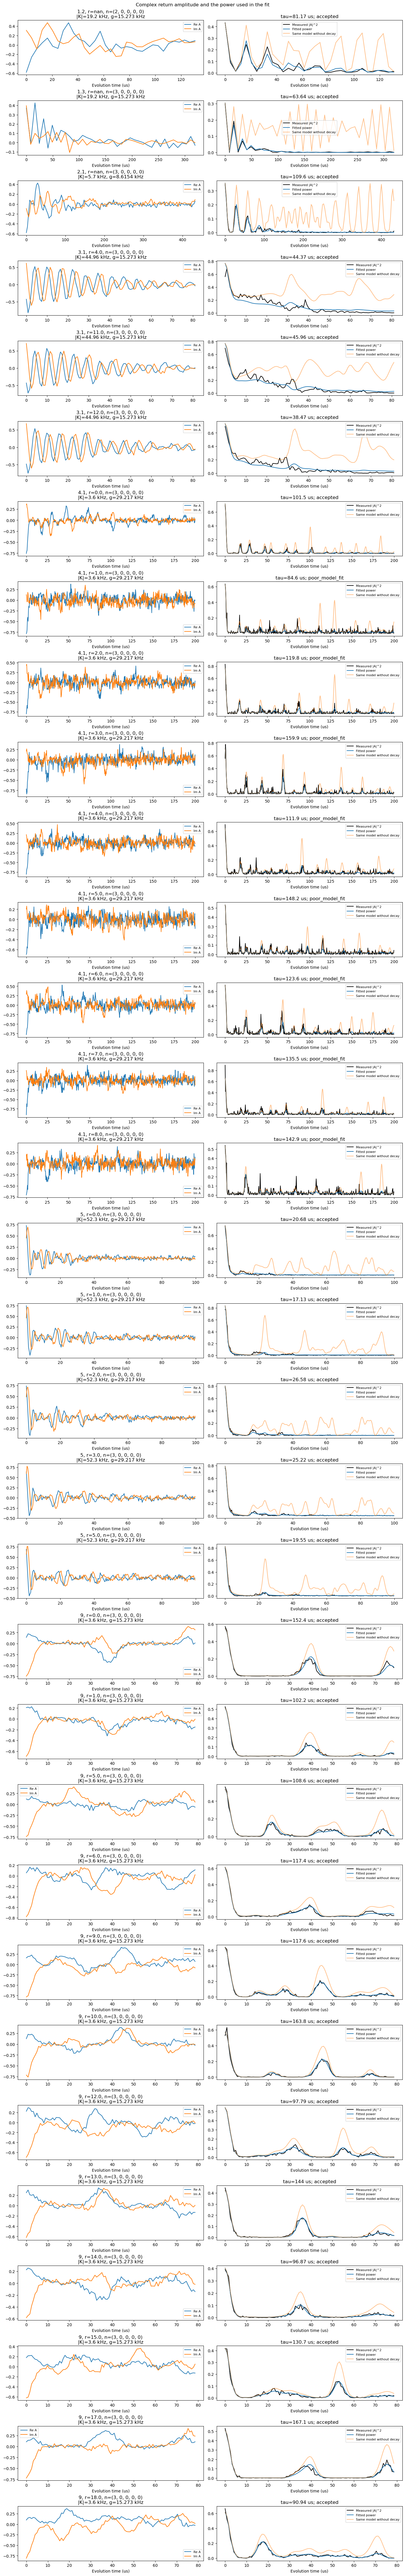

In [46]:
show_trace_fits(fit_results, fit_details)

## 6. Mean decay time versus Kerr

All g values share one figure: central 2 photons on the left, 3 photons on the right.
The legend identifies g, total N, storage modes, and disorder. Each point remains a
mean +/- 1 sample SD within the same K/g/N/mode/disorder condition; g values are
not pooled. `KERR_PURE_CENTRAL=True` keeps all other modes empty.


In [ ]:
def summary_frame(results):
    """Keep accepted fits and identify the measured physical conditions."""
    frame = results.loc[results.accepted].copy()
    if frame.empty:
        raise ValueError("No accepted fits. Inspect the fit status table and measured traces.")
    frame["g_key"] = frame.g_kHz.map(lambda g: tuple(np.round(g, 9)))
    frame["mode_set"] = frame.mode_labels.map(tuple)
    frame["D_kHz"] = frame.disorder_strength_kHz.round(6)
    frame["D_label"] = frame.disorder_strength_source.map(
        lambda source: "strength" if source.startswith("saved") else "RMS")
    return frame


def draw_mean_sd(axis, frame, x_column, label=None, color=None):
    means = frame.groupby(x_column).tau_us.agg(["mean", "std", "count"])
    dots, = axis.plot(means.index, means["mean"], "o", label=label, color=color)
    repeated = means.loc[means["count"] > 1]
    axis.errorbar(repeated.index, repeated["mean"], yerr=repeated["std"],
                   fmt="none", color=dots.get_color(), capsize=4)
    x_values = means.index.to_numpy()
    for index, (x, row) in enumerate(means.iterrows()):
        near_next = index + 1 < len(x_values) and x_values[index + 1] - x < 0.06 * np.ptp(axis.get_xlim())
        axis.annotate(f"n={int(row['count'])}", (x, row["mean"]),
                       xytext=(-8, 7) if near_next else (8, 7),
                       ha="right" if near_next else "left", textcoords="offset points", fontsize=8)
    axis.set_ylabel("Mean amplitude decay time (us)")
    axis.grid(alpha=0.2)
    axis.margins(x=0.15, y=0.15)


def condition_title(frame):
    row = frame.iloc[0]
    return (f"g={row.g_mean_kHz:.5g} kHz, N={row.total_photons}; "
            f"{','.join(row.mode_set[1:])}; {row.D_label}={row.D_kHz:g} kHz")


def show_kerr_overview(frame):
    frame = frame.loc[frame.n_central.isin([2, 3])]
    if KERR_PURE_CENTRAL:
        frame = frame.loc[frame.pure_central]
    if frame.empty:
        print("No accepted traces have the selected central photon numbers.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
    groups = list(frame.groupby(CONDITION_COLUMNS))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    for axis, n in zip(axes, [2, 3]):
        for index, (_, group) in enumerate(groups):
            selected = group.loc[group.n_central.eq(n)]
            if selected.empty:
                continue
            draw_mean_sd(axis, selected, "K_kHz", condition_title(group), colors[index % len(colors)])
        axis.set(title=f"Initial central photons = {n}",
                 xlabel="Self-Kerr magnitude |K| (kHz)")
        axis.legend(title="g / N / storage modes / disorder", fontsize=8, title_fontsize=9)
    fig.suptitle(f"{PLOT_ENVELOPE}: mean +/- 1 sample SD; n = accepted traces")
    plt.show()

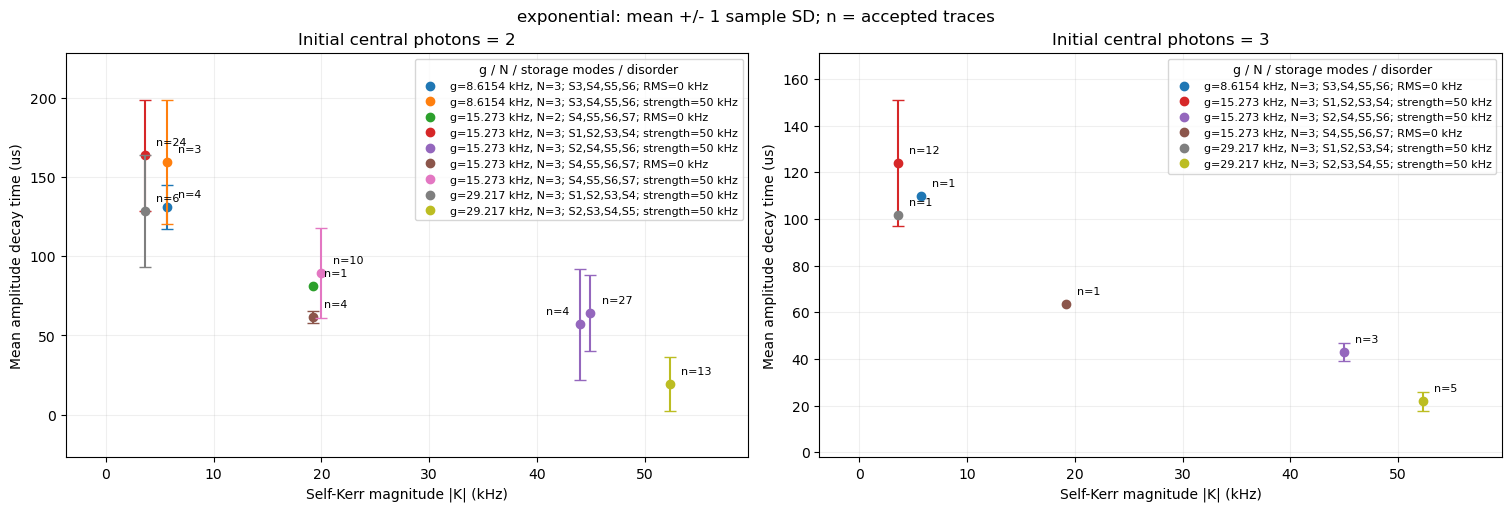

In [ ]:
accepted = summary_frame(fit_results)
CONDITION_COLUMNS = ["g_key", "total_photons", "mode_set", "D_label", "D_kHz"]
show_kerr_overview(accepted)

## 7. Kerr dependence of each full occupation

Each occupation is averaged only over its matching realizations. Mode sets
and disorder strengths have separate panels. Some conditions contain one K.


In [49]:
def show_occupation_kerr(frame):
    frame = frame.loc[frame.n_central.isin([2, 3])]
    if KERR_PURE_CENTRAL:
        frame = frame.loc[frame.pure_central]
    groups = list(frame.groupby(CONDITION_COLUMNS))
    if not groups:
        return
    fig, axes = plt.subplots(len(groups), 1, figsize=(10, 3.2 * len(groups)),
                             squeeze=False, constrained_layout=True)
    for axis, (_, group) in zip(axes[:, 0], groups):
        for occupation, values in group.groupby("occupation"):
            draw_mean_sd(axis, values, "K_kHz", str(occupation))
        axis.set(title=condition_title(group), xlabel="Self-Kerr magnitude |K| (kHz)")
        axis.legend(title="Full initial occupation", fontsize=8)
    fig.suptitle("Each occupation: mean +/- 1 sample SD")
    plt.show()

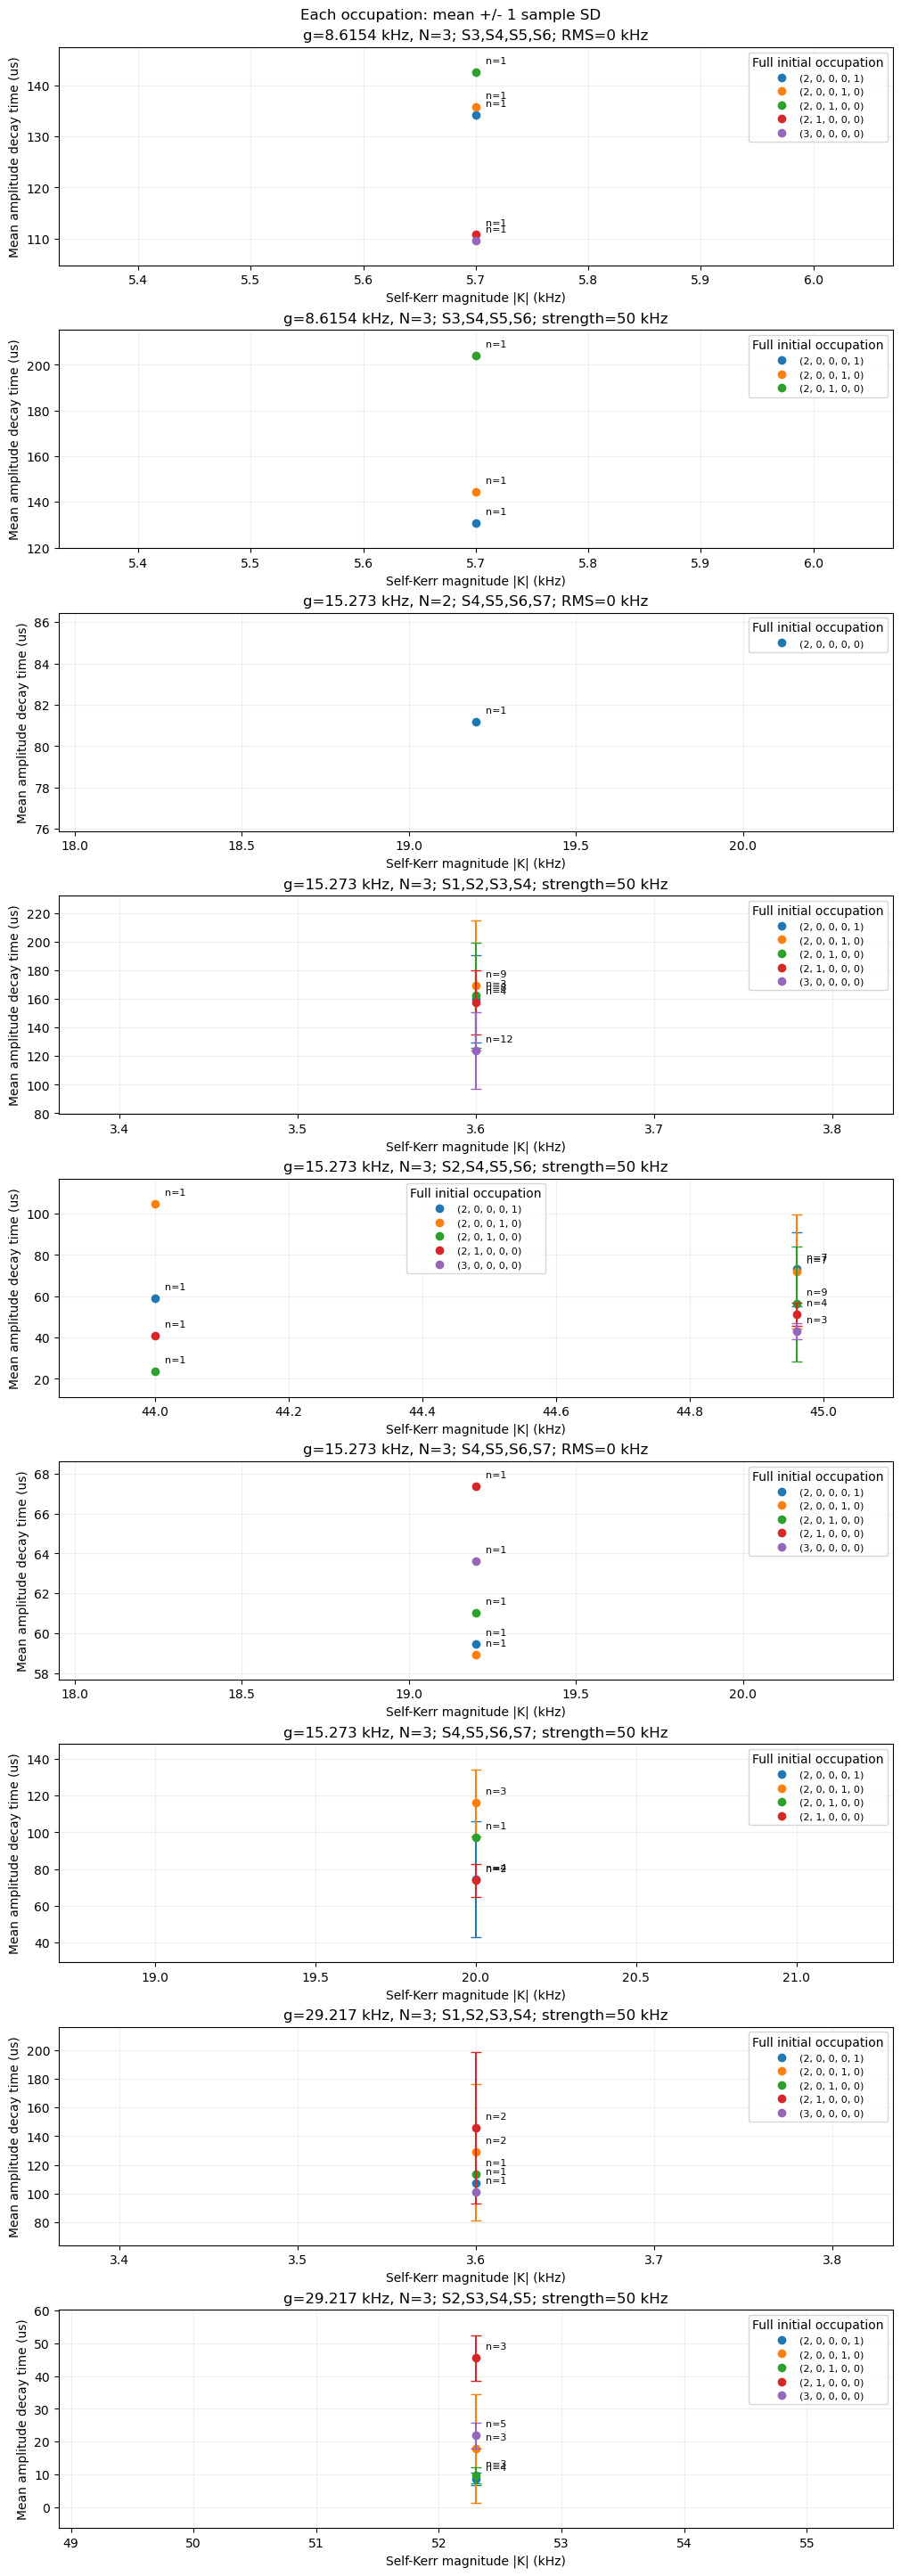

In [50]:
show_occupation_kerr(accepted)

## 8. Photon number at fixed Kerr

Each condition has a mean and sample SD at every acquired photon number.
Change `PHOTON_VIEW_MODE` to inspect a storage mode. Other occupations may
differ within each average.


In [51]:
def show_photon_dependence(frame):
    column = f"n_{PHOTON_VIEW_MODE}"
    frame = frame.loc[frame[column].notna()]
    groups = list(frame.groupby(["K_kHz", *CONDITION_COLUMNS]))
    fig, axes = plt.subplots(len(groups), 1, figsize=(10, 3.1 * len(groups)),
                             squeeze=False, constrained_layout=True)
    for axis, (key, group) in zip(axes[:, 0], groups):
        draw_mean_sd(axis, group, column)
        axis.set(title=f"|K|={key[0]:g} kHz; {condition_title(group)}",
                  xlabel=f"Initial photon number in {PHOTON_VIEW_MODE}")
        axis.set_xticks(sorted(group[column].unique()))
    fig.suptitle("Photon-number dependence: mean +/- 1 sample SD")
    plt.show()

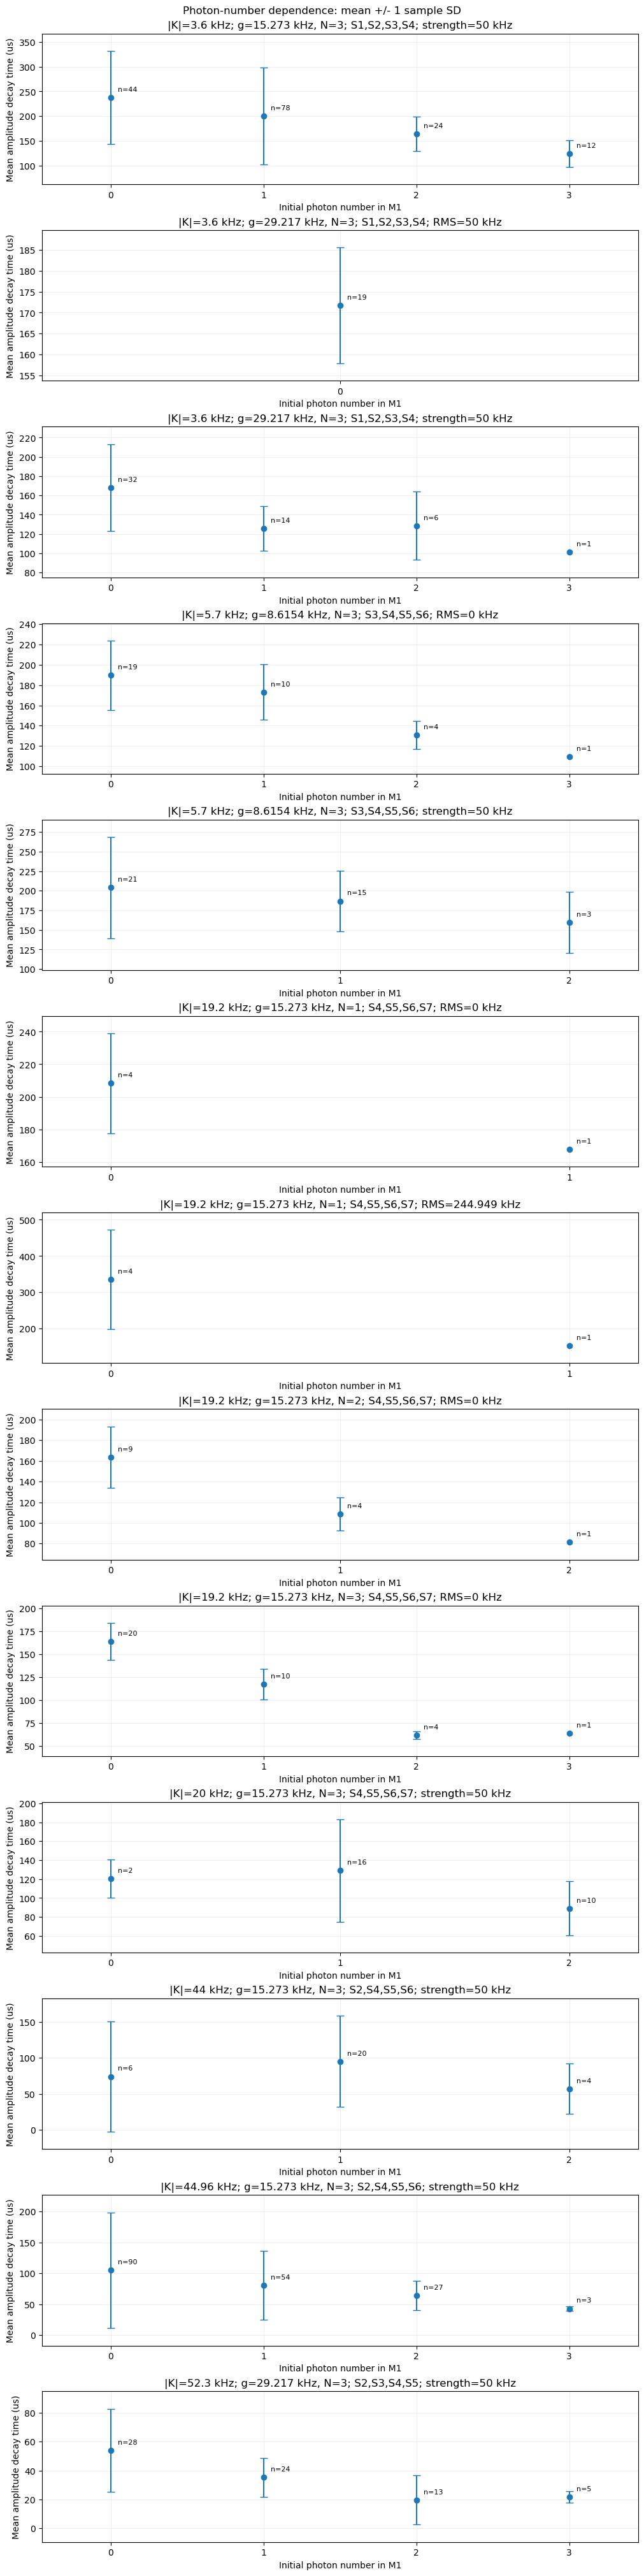

In [52]:
show_photon_dependence(accepted)

## 9. Kerr / photon-number map

Mean tau and trace count at measured combinations; missing combinations stay blank.

In [53]:
def show_decay_map(frame):
    column = f"n_{PHOTON_VIEW_MODE}"
    frame = frame.loc[frame[column].notna()]
    groups = list(frame.groupby(CONDITION_COLUMNS))
    maps = [group.pivot_table(index=column, columns="K_kHz", values="tau_us", aggfunc="mean")
            for _, group in groups]
    values = np.concatenate([table.to_numpy().ravel() for table in maps])
    fig, axes = plt.subplots(len(groups), 1, figsize=(10, 3.4 * len(groups)),
                             squeeze=False, constrained_layout=True)
    for axis, (_, group), table in zip(axes[:, 0], groups, maps):
        counts = group.pivot_table(index=column, columns="K_kHz", values="tau_us", aggfunc="count")
        image = axis.imshow(table, origin="lower", aspect="auto",
                             vmin=np.nanmin(values), vmax=np.nanmax(values), cmap="viridis")
        axis.set_xticks(range(len(table.columns)), [f"{x:g}" for x in table.columns])
        axis.set_yticks(range(len(table.index)), [f"{n:g}" for n in table.index])
        for i, j in np.argwhere(np.isfinite(table.to_numpy())):
            axis.text(j, i, f"{table.iloc[i, j]:.3g}\n(n={int(counts.iloc[i, j])})",
                       ha="center", va="center", color="white")
        axis.set(title=condition_title(group), xlabel="Self-Kerr magnitude |K| (kHz)",
                  ylabel=f"Initial photon number in {PHOTON_VIEW_MODE}")
        fig.colorbar(image, ax=axis, label="Mean amplitude decay time (us)")
    fig.suptitle("Kerr / photon-number map; measured combinations only")
    plt.show()

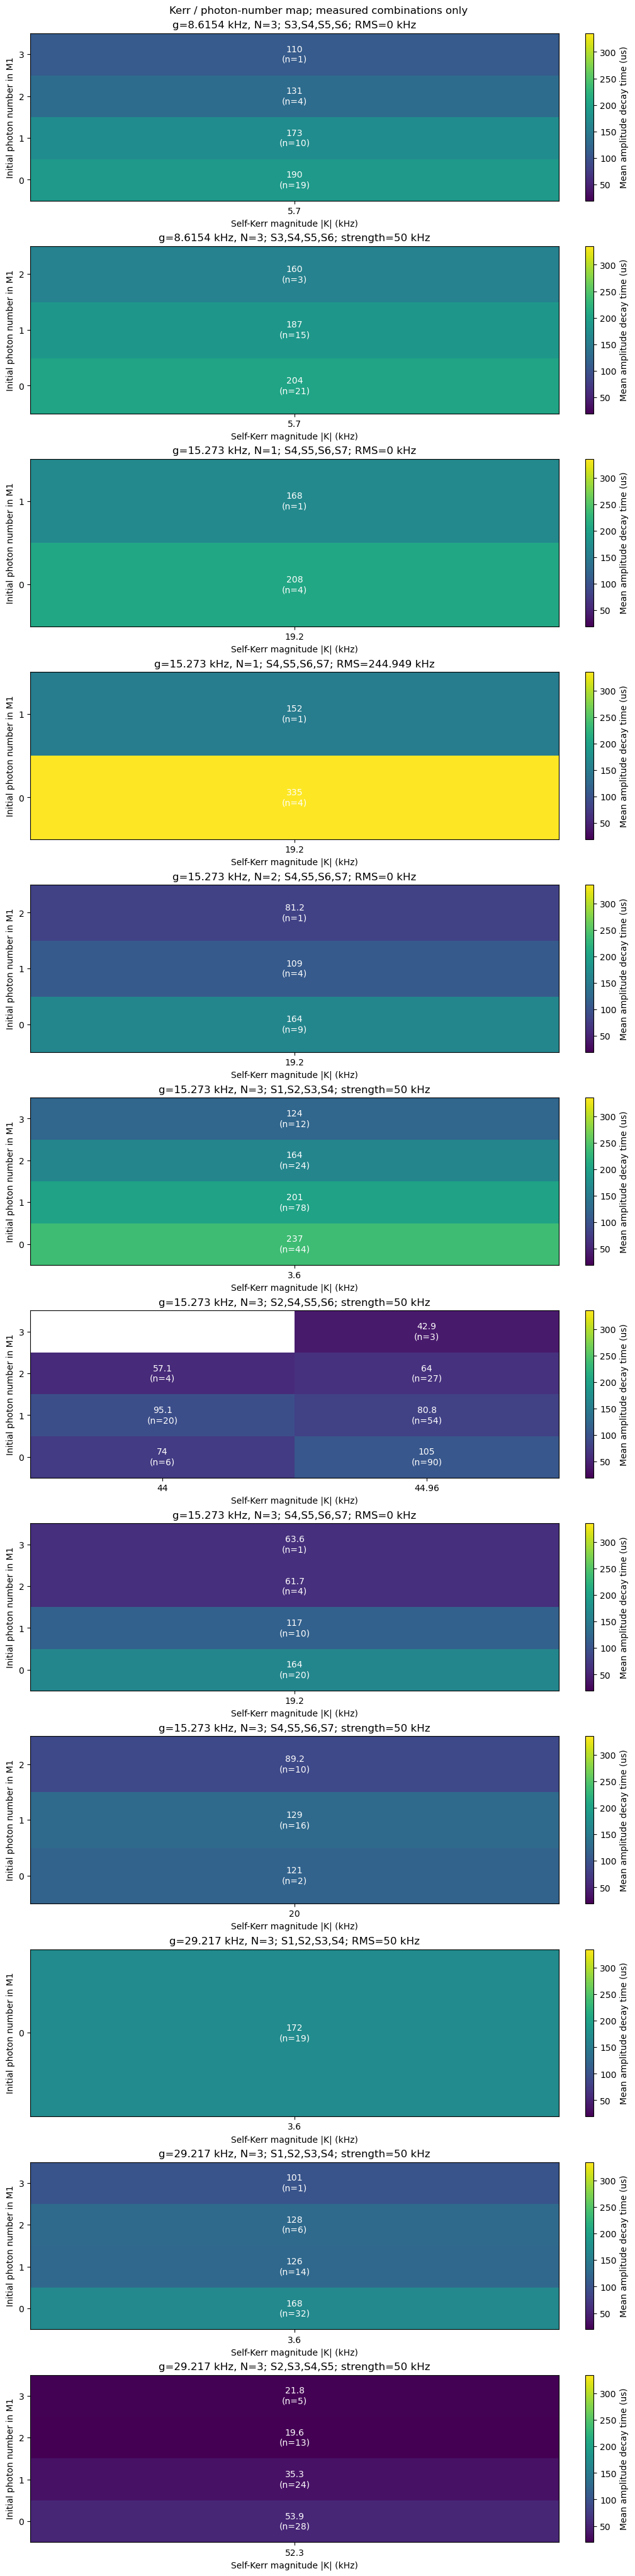

In [54]:
show_decay_map(accepted)

## Access one occupation

The measured complex amplitude, fitted power, and complete JOB provenance are
available directly in memory. Edit the selection below for another occupation.


In [55]:
# Example: central cavity initially contains three photons in dataset 1.3.
# trace = next(t for t in traces if t["dataset_id"] == "1.3" and t["n_central"] == 3)
# print("Spectroscopy JOB IDs:", ", ".join(trace["job_ids"]))
# print("Calibration reference JOB IDs:", ", ".join(trace["calibration_job_ids"]))
# time_us, complex_A = trace["time_us"], trace["A"]
# fitted_power = fit_details[trace["trace_id"]]["fit"]["model_power"]